<a href="https://colab.research.google.com/github/nevita275/PCVK26_20_Triya/blob/main/Week5_20_Triya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEL IDENTITAS

NAMA : Nevita Triya Yuliana
NIM : 244107020208 | N = 208
bins   : 8
clip   : 2.5
tile   : 2
L      : 4
WAKTU : 2026-09-26 21:39:21 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : c1591ac254be954d


Text(0.5, 1.0, '244107020208 - CLAHE clip 2.5')

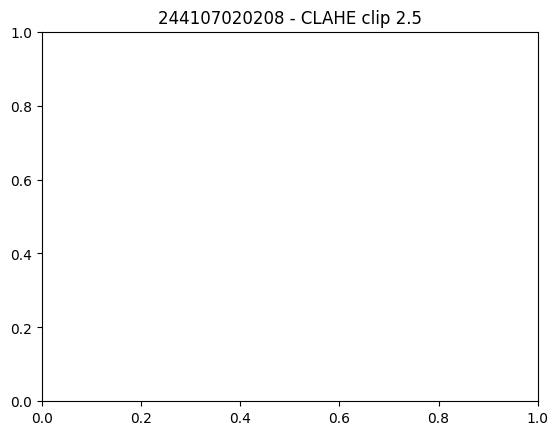

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
import matplotlib.pyplot as plt

NAMA = 'Nevita Triya Yuliana'
NIM = '244107020208'

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L'   : 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

# Hubungkan ke Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Library

In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# Fungsi Bantu Baca Citra

In [4]:
def safe_imread(path, flags=cv.IMREAD_COLOR):
    if os.path.exists(path):
        img = cv.imread(path, flags)
        if img is not None:
            return img
    base, ext = os.path.splitext(path)
    for alt_ext in ['.jpg', '.jpeg', '.JPG', '.JPEG', '.png', '.PNG']:
        alt_path = base + alt_ext
        if os.path.exists(alt_path):
            img = cv.imread(alt_path, flags)
            if img is not None:
                print(f'Info: dibaca dari {alt_path} (bukan {path})')
                return img
    raise FileNotFoundError(f'Tidak ditemukan file untuk: {path}')

# Setup Folder & Cek Nama File

In [5]:
NIM_STR = '244107020208'
CONTOH = '/content/drive/MyDrive/PVCK/Images'
BASE   = '/content/drive/MyDrive/PVCK/Images/' + NIM_STR

print('Isi folder CONTOH:', os.listdir(CONTOH))
print('Isi folder BASE  :', os.listdir(BASE))

Isi folder CONTOH: ['galaxy.jpg', '244107020208', 'houses.JPG', 'noises']
Isi folder BASE  : ['KTM1b.jpeg', 'KTM1a.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg', 'NIGHT1.jpeg', 'OBJ1.jpeg', 'lena.jpg', 'lena_lc.jpg']


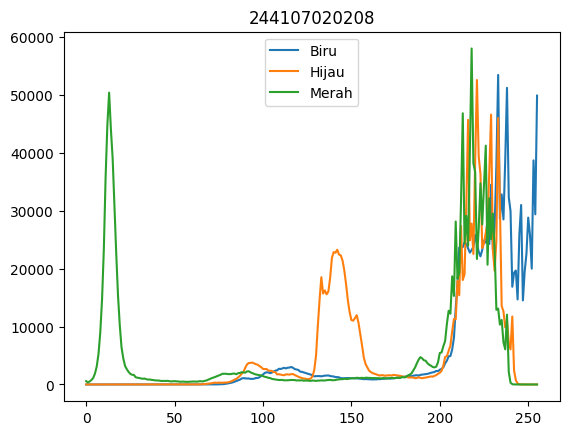

In [6]:
import numpy as np, cv2 as cv, matplotlib.pyplot as plt

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)           # 1. siapkan penghitung, isi 0
    for y in range(img.shape[0]):             # 2. telusuri setiap baris
        for x in range(img.shape[1]):         # dan setiap kolom
            h[img[y, x]] += 1                 # 3. tambah 1 sesuai nilai piksel
    return h

gray = safe_imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)
h = histogram_manual(gray)
p = h / gray.size                              # 4. normalisasi, jumlahnya = 1
cdf = np.cumsum(p)                             # 5. distribusi kumulatif
assert h.sum() == gray.size                    # pemeriksaan wajib

# citra berwarna: ulangi untuk tiap kanal
bgr = safe_imread(BASE + '/KTM1d.jpeg')
for i, nama in enumerate(['Biru', 'Hijau', 'Merah']):
    plt.plot(histogram_manual(bgr[:, :, i]), label=nama)
plt.legend()
plt.title(NIM)
plt.show()

# E-1 PERCOBAAN HISTOGRAM
## Tahap 1: Menggunakan citra contoh lena.jpg

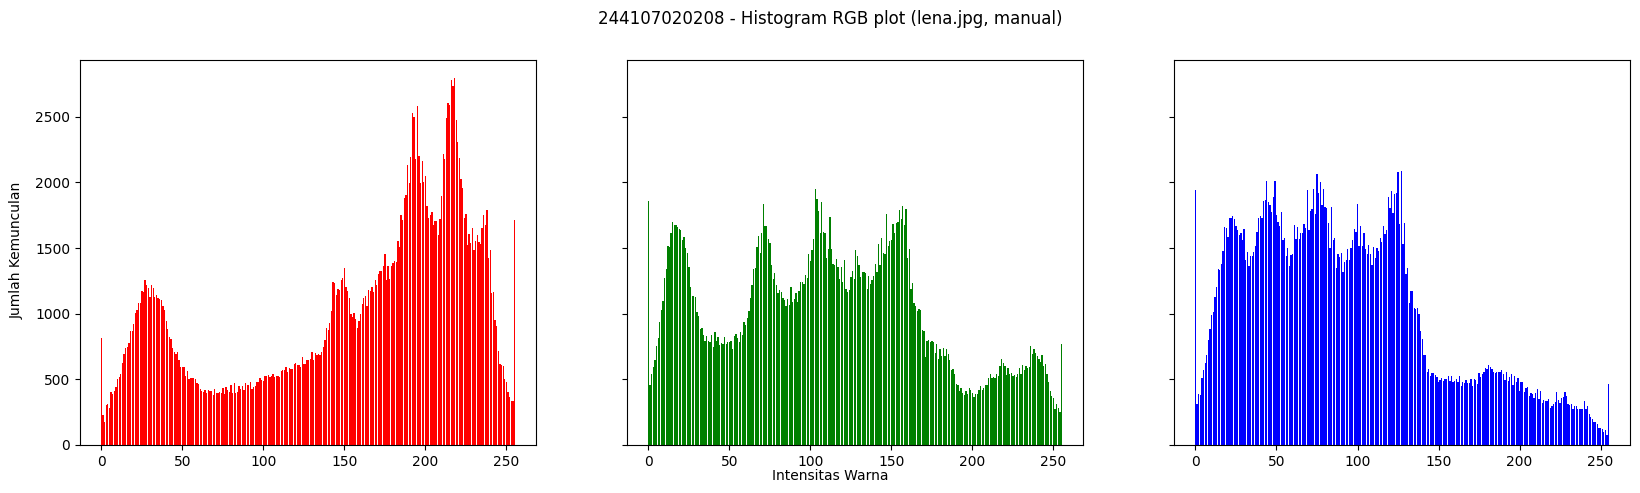

In [7]:
img = safe_imread(f'{BASE}/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (lena.jpg, manual)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

## Tahap 2: Menggunakan KTM1b

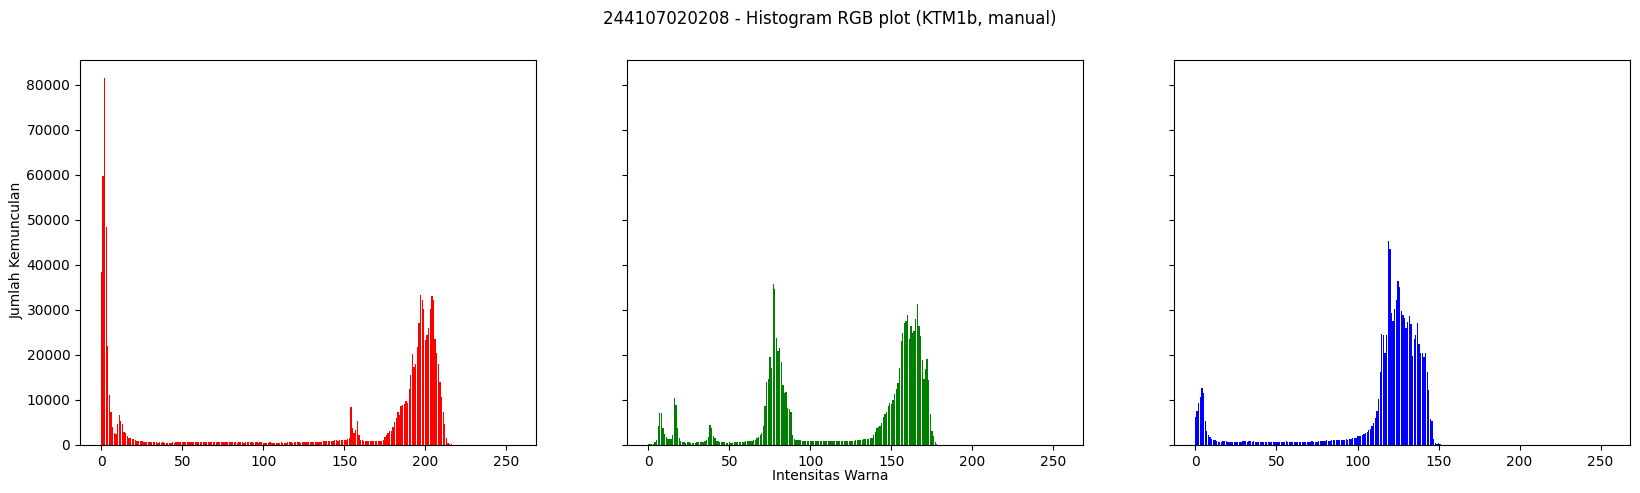

In [8]:
img2 = safe_imread(f'{BASE}/KTM1b.jpeg')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img2)

red2 = [0]*256
green2 = [0]*256
blue2 = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red2[img2[y][x][0]] += 1
        green2[img2[y][x][1]] += 1
        blue2[img2[y][x][2]] += 1

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (KTM1b, manual)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red2, color='red')
axs[1].bar(names, green2, color='green')
axs[2].bar(names, blue2, color='blue')
plt.show()

# Jawab Pertanyaan Praktikum E1
## 1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [9]:
def hist_numpy(channel):
    h, _ = np.histogram(channel, bins=256, range=(0,256))
    return h

def hist_cv(channel):
    h = cv.calcHist([channel], [0], None, [256], [0,256])
    return h.flatten().astype(int)

# --- lena.jpg ---
img_bgr = safe_imread(f'{BASE}/lena.jpg')
r_manual = np.array(red);  g_manual = np.array(green);  b_manual = np.array(blue)

r_np = hist_numpy(img_bgr[:,:,2]); g_np = hist_numpy(img_bgr[:,:,1]); b_np = hist_numpy(img_bgr[:,:,0])
r_cv = hist_cv(img_bgr[:,:,2]);    g_cv = hist_cv(img_bgr[:,:,1]);    b_cv = hist_cv(img_bgr[:,:,0])

print('=== lena.jpg ===')
print('Selisih maks Manual vs NumPy (R,G,B):', np.max(np.abs(r_manual-r_np)), np.max(np.abs(g_manual-g_np)), np.max(np.abs(b_manual-b_np)))
print('Selisih maks Manual vs CV    (R,G,B):', np.max(np.abs(r_manual-r_cv)), np.max(np.abs(g_manual-g_cv)), np.max(np.abs(b_manual-b_cv)))

# --- KTM1b.jpg ---
img2_bgr = safe_imread(f'{BASE}/KTM1b.jpeg')
r_manual2 = np.array(red2); g_manual2 = np.array(green2); b_manual2 = np.array(blue2)

r_np2 = hist_numpy(img2_bgr[:,:,2]); g_np2 = hist_numpy(img2_bgr[:,:,1]); b_np2 = hist_numpy(img2_bgr[:,:,0])
r_cv2 = hist_cv(img2_bgr[:,:,2]);    g_cv2 = hist_cv(img2_bgr[:,:,1]);    b_cv2 = hist_cv(img2_bgr[:,:,0])

print('=== KTM1b.jpg (' + NIM + ') ===')
print('Selisih maks Manual vs NumPy (R,G,B):', np.max(np.abs(r_manual2-r_np2)), np.max(np.abs(g_manual2-g_np2)), np.max(np.abs(b_manual2-b_np2)))
print('Selisih maks Manual vs CV    (R,G,B):', np.max(np.abs(r_manual2-r_cv2)), np.max(np.abs(g_manual2-g_cv2)), np.max(np.abs(b_manual2-b_cv2)))

=== lena.jpg ===
Selisih maks Manual vs NumPy (R,G,B): 0 0 0
Selisih maks Manual vs CV    (R,G,B): 0 0 0
=== KTM1b.jpg (244107020208) ===
Selisih maks Manual vs NumPy (R,G,B): 0 0 0
Selisih maks Manual vs CV    (R,G,B): 0 0 0


## 2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi pencahayaan saat akuisisi pada Pertemuan 2

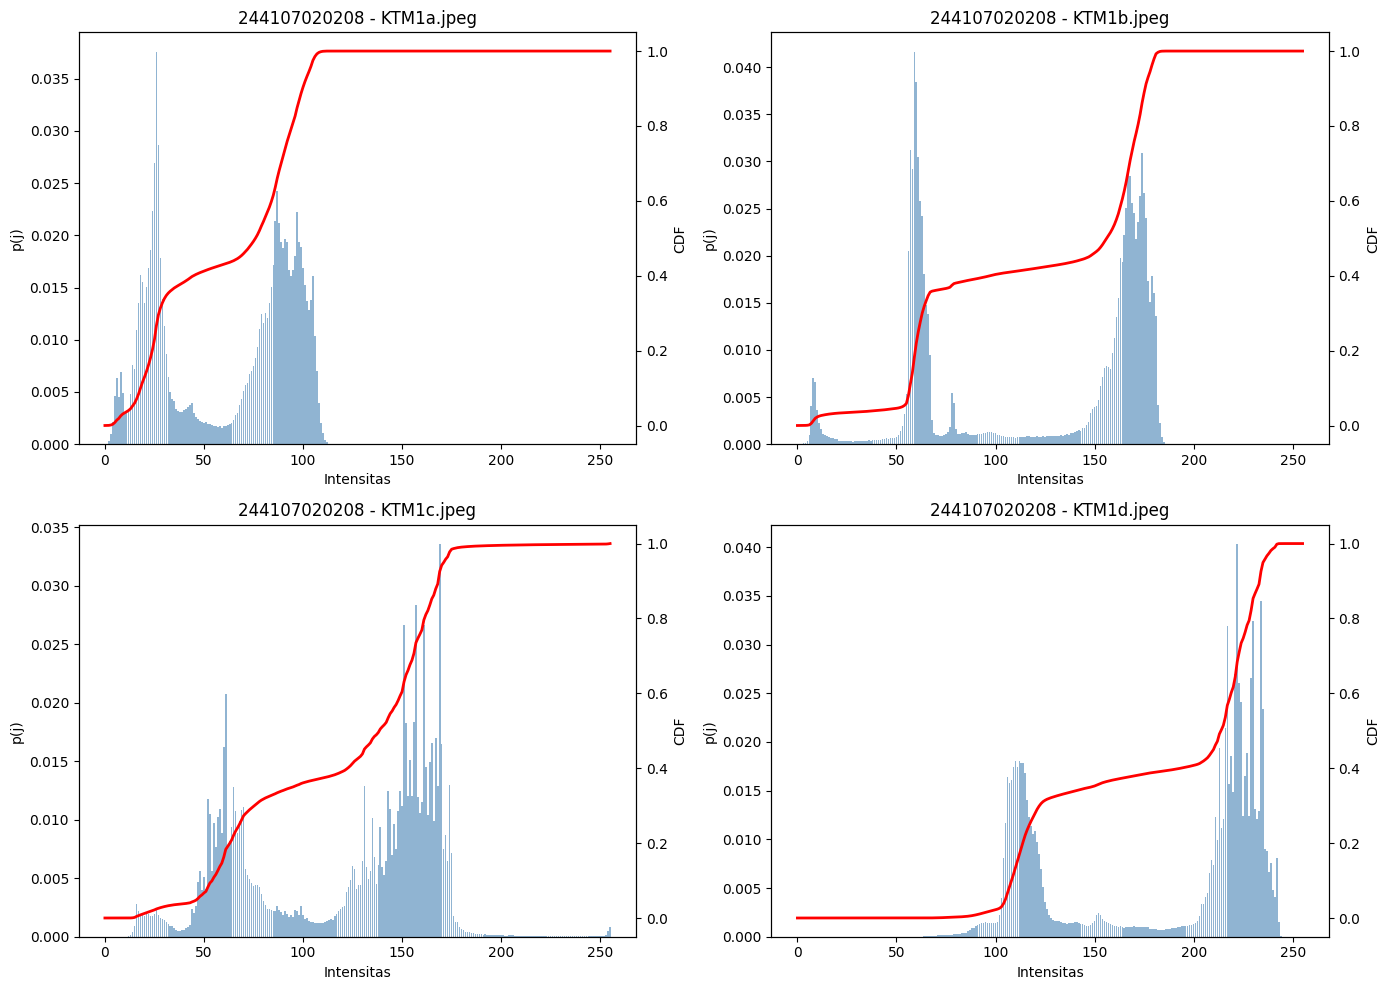

Rerata intensitas tiap citra:
KTM1a.jpeg: 62.09
KTM1b.jpeg: 122.08
KTM1c.jpeg: 119.46
KTM1d.jpeg: 182.29


In [10]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))
axs = axs.ravel()

nama_file_list = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']
rerata_intensitas = {}

for i, fname in enumerate(nama_file_list):
    gray = cv.cvtColor(safe_imread(f'{BASE}/{fname}'), cv.COLOR_BGR2GRAY)
    h, _ = np.histogram(gray, bins=256, range=(0,256))
    p = h / gray.size
    cdf = np.cumsum(p)

    ax2 = axs[i].twinx()
    axs[i].bar(np.arange(256), p, color='steelblue', alpha=0.6, label='p(j)')
    ax2.plot(np.arange(256), cdf, color='red', linewidth=2, label='CDF')
    axs[i].set_title(NIM + f' - {fname}')
    axs[i].set_xlabel('Intensitas'); axs[i].set_ylabel('p(j)'); ax2.set_ylabel('CDF')

    rerata_intensitas[fname] = gray.mean()

plt.tight_layout()
plt.show()

print('Rerata intensitas tiap citra:')
for k, v in rerata_intensitas.items():
    print(f'{k}: {v:.2f}')

## 3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.

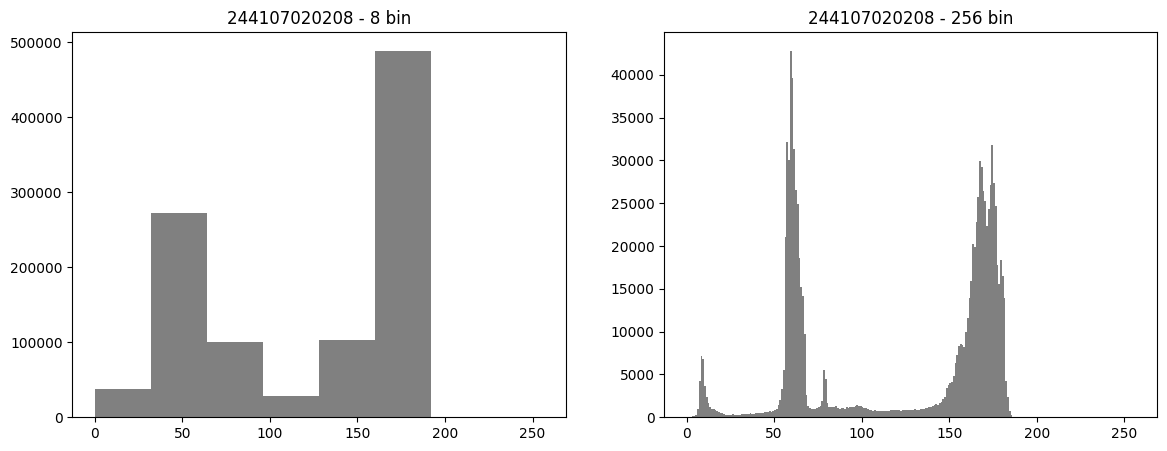

In [11]:
gray_b = cv.cvtColor(safe_imread(f'{BASE}/KTM1b.jpeg'), cv.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1, 2, figsize=(14,5))
ax[0].hist(gray_b.ravel(), bins=PARAM['bins'], range=(0,256), color='gray')
ax[0].set_title(NIM + f" - {PARAM['bins']} bin")
ax[1].hist(gray_b.ravel(), bins=256, range=(0,256), color='gray')
ax[1].set_title(NIM + ' - 256 bin')
plt.show()

# E-2 PERCOBAAN HISTOGRAM EQUALIZATION
## No.1-Tahap 1: Menggunakan citra contoh lena_lc

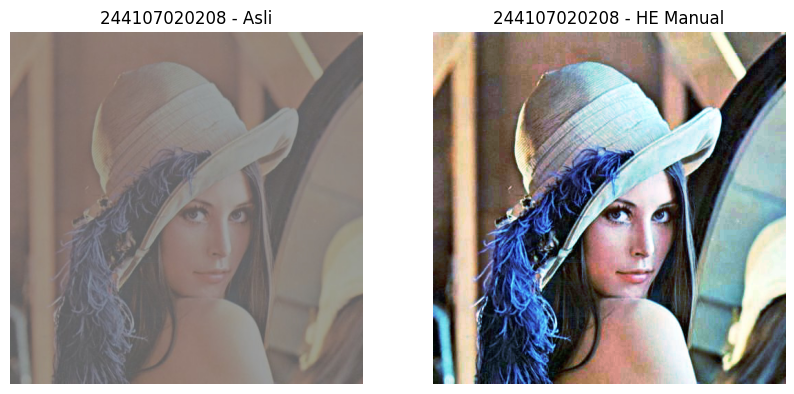

In [17]:
def histogram_equalization_manual_channel(channel):
    """HE manual untuk SATU kanal warna (2D array)"""
    h_img, w_img = channel.shape
    h_hist, _ = np.histogram(channel, bins=256, range=(0,256))
    p = h_hist / (h_img * w_img)
    cdf = np.cumsum(p)
    Ko = np.round(cdf * 255).astype(np.uint8)
    return Ko[channel]

def histogram_equalization_manual_color(bgr):
    """Terapkan HE manual ke tiap kanal B, G, R secara terpisah"""
    b, g, r = cv.split(bgr)
    b_eq = histogram_equalization_manual_channel(b)
    g_eq = histogram_equalization_manual_channel(g)
    r_eq = histogram_equalization_manual_channel(r)
    return cv.merge([b_eq, g_eq, r_eq])

bgr_lc = safe_imread(f'{BASE}/lena_lc.jpg')
he_manual_lena = histogram_equalization_manual_color(bgr_lc)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(cv.cvtColor(bgr_lc, cv.COLOR_BGR2RGB)); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(he_manual_lena, cv.COLOR_BGR2RGB)); ax[1].set_title(NIM + ' - HE Manual'); ax[1].axis('off')
plt.show()

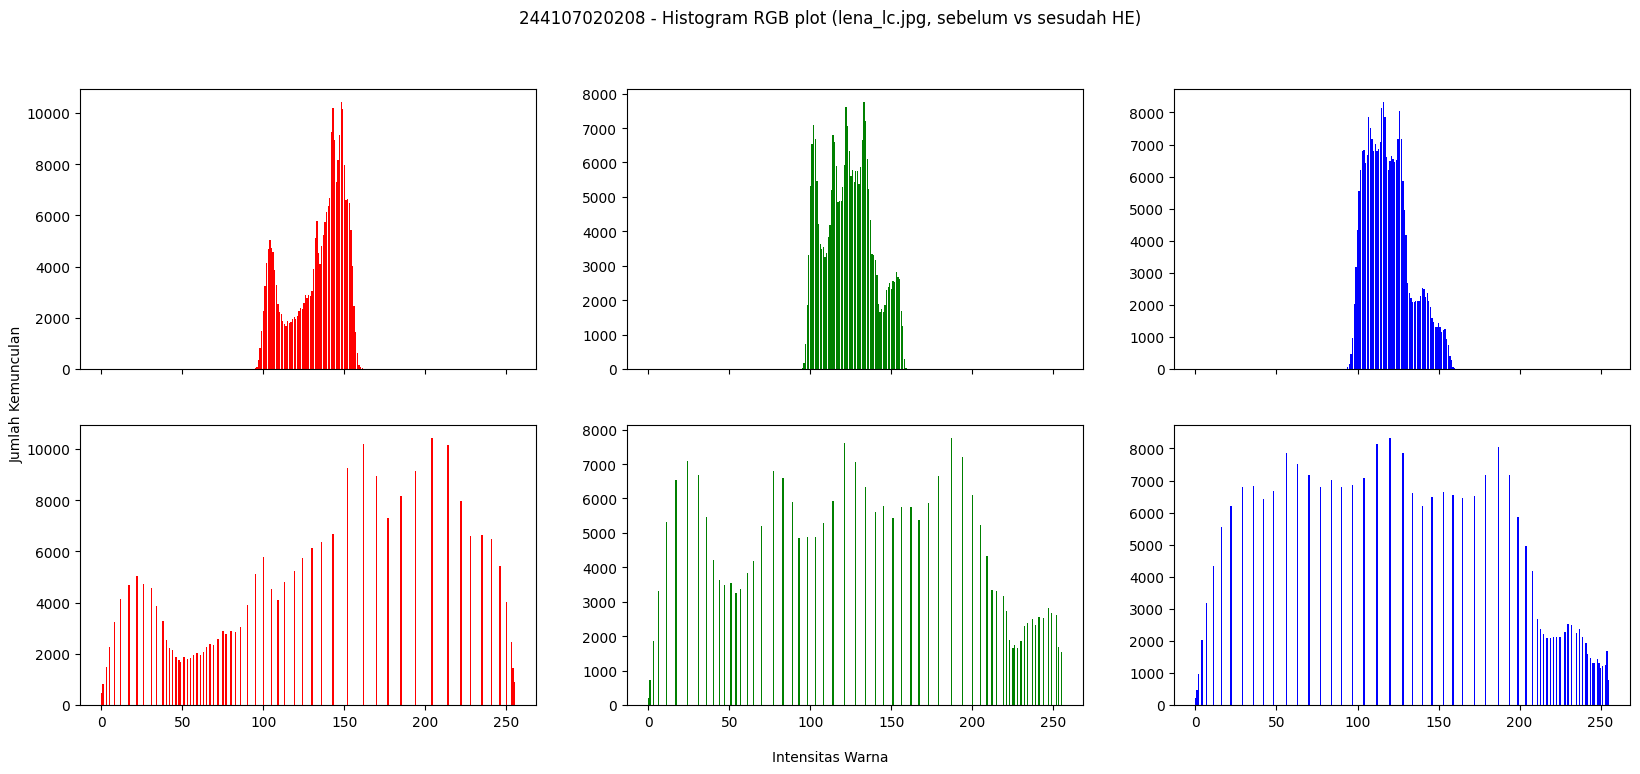

In [19]:
def he_cv_color(bgr):
    b, g, r = cv.split(bgr)
    b_equalized = cv.equalizeHist(b)
    g_equalized = cv.equalizeHist(g)
    r_equalized = cv.equalizeHist(r)
    return cv.merge([b_equalized, g_equalized, r_equalized])

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

names = np.arange(256)

bgr_lc = safe_imread(f'{BASE}/lena_lc.jpg')
he_cv_lena_rgb = he_cv_color(bgr_lc)

fig, axs = plt.subplots(2, 3, figsize=[20,8], sharex=True, sharey=False)
fig.suptitle(NIM + ' - Histogram RGB plot (lena_lc.jpg, sebelum vs sesudah HE)')

# baris atas: sebelum HE
axs[0,0].bar(names, histogram_manual(bgr_lc[:,:,2]), color='red')
axs[0,1].bar(names, histogram_manual(bgr_lc[:,:,1]), color='green')
axs[0,2].bar(names, histogram_manual(bgr_lc[:,:,0]), color='blue')

# baris bawah: sesudah HE
axs[1,0].bar(names, histogram_manual(he_cv_lena_rgb[:,:,2]), color='red')
axs[1,1].bar(names, histogram_manual(he_cv_lena_rgb[:,:,1]), color='green')
axs[1,2].bar(names, histogram_manual(he_cv_lena_rgb[:,:,0]), color='blue')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
plt.show()

## No.1-Tahap 2: Menggunakan KTM1a

In [20]:
def histogram_equalization_manual(gray):
    h_img, w_img = gray.shape
    h_hist, _ = np.histogram(gray, bins=256, range=(0,256))
    p = h_hist / (h_img*w_img)
    cdf = np.cumsum(p)
    Ko = np.round(cdf * 255).astype(np.uint8)
    hasil = Ko[gray]
    return hasil

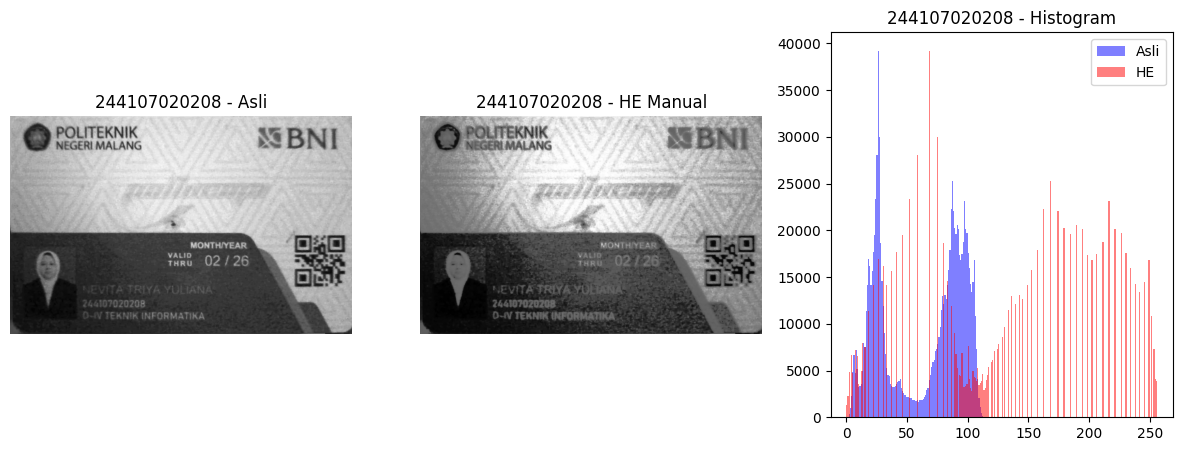

PSNR (Asli vs HE Manual): 10.133443710113763 dB


In [21]:
def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

gray_a = cv.cvtColor(safe_imread(f'{BASE}/KTM1a.jpeg'), cv.COLOR_BGR2GRAY)
he_manual_a = histogram_equalization_manual(gray_a)

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].imshow(gray_a, cmap='gray'); axs[0].set_title(NIM + ' - Asli'); axs[0].axis('off')
axs[1].imshow(he_manual_a, cmap='gray'); axs[1].set_title(NIM + ' - HE Manual'); axs[1].axis('off')
axs[2].hist(gray_a.ravel(), bins=256, range=(0,256), alpha=0.5, label='Asli', color='blue')
axs[2].hist(he_manual_a.ravel(), bins=256, range=(0,256), alpha=0.5, label='HE', color='red')
axs[2].legend(); axs[2].set_title(NIM + ' - Histogram')
plt.show()

psnr_val = PSNR(gray_a, he_manual_a)
print('PSNR (Asli vs HE Manual):', psnr_val, 'dB')

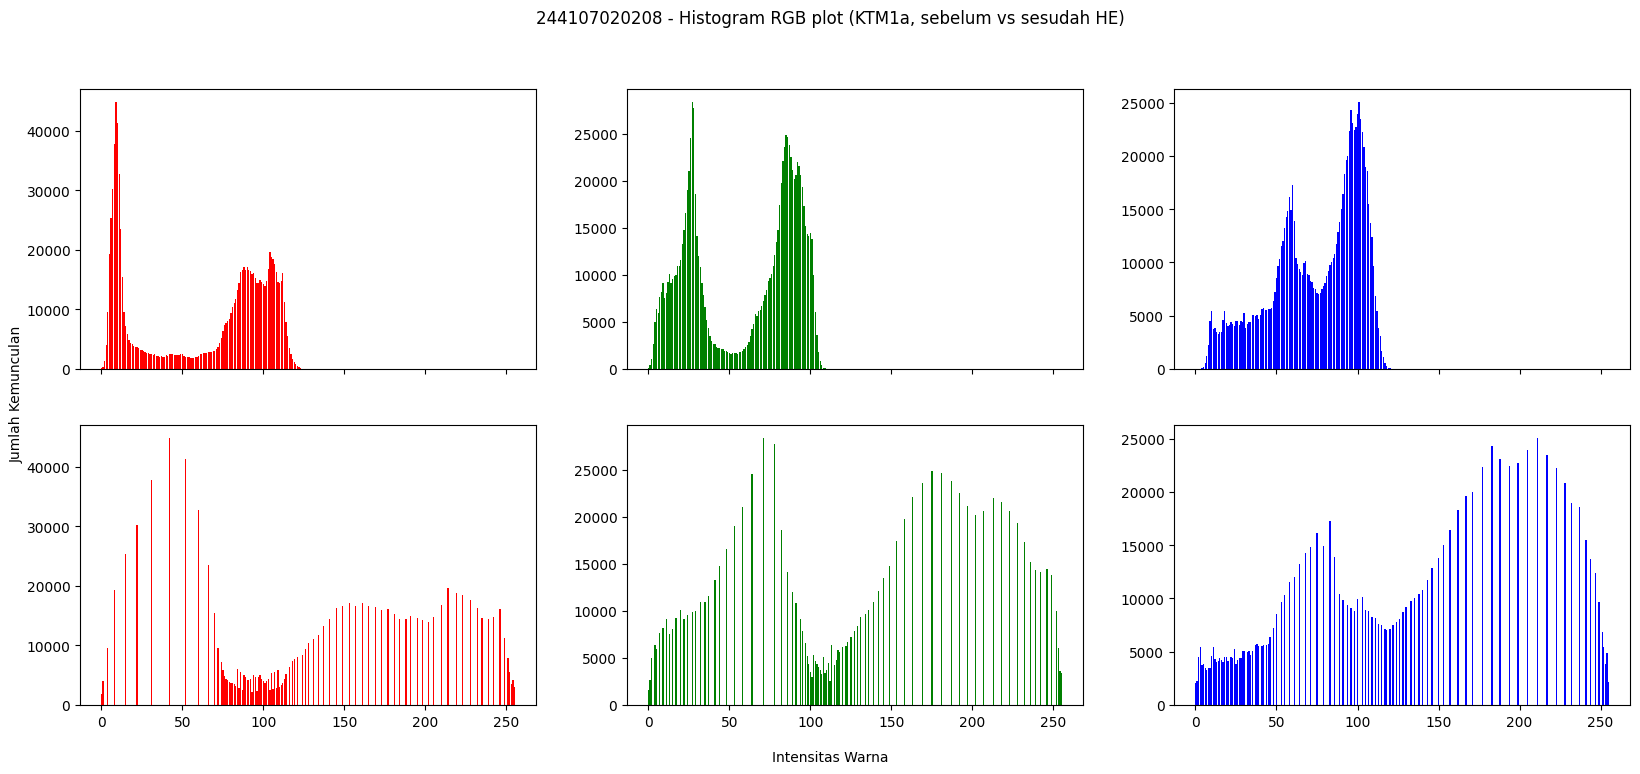

In [22]:
bgr_ktm1a = safe_imread(f'{BASE}/KTM1a.jpeg')
he_cv_ktm1a_rgb = he_cv_color(bgr_ktm1a)

fig, axs = plt.subplots(2, 3, figsize=[20,8], sharex=True, sharey=False)
fig.suptitle(NIM + ' - Histogram RGB plot (KTM1a, sebelum vs sesudah HE)')

# baris atas: sebelum HE
axs[0,0].bar(names, histogram_manual(bgr_ktm1a[:,:,2]), color='red')
axs[0,1].bar(names, histogram_manual(bgr_ktm1a[:,:,1]), color='green')
axs[0,2].bar(names, histogram_manual(bgr_ktm1a[:,:,0]), color='blue')

# baris bawah: sesudah HE
axs[1,0].bar(names, histogram_manual(he_cv_ktm1a_rgb[:,:,2]), color='red')
axs[1,1].bar(names, histogram_manual(he_cv_ktm1a_rgb[:,:,1]), color='green')
axs[1,2].bar(names, histogram_manual(he_cv_ktm1a_rgb[:,:,0]), color='blue')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
plt.show()

## No.2-Lengkapi kode equalizeHist & Bandingkan dengan Manual

Selisih maksimum (lena_lc.jpg): 0


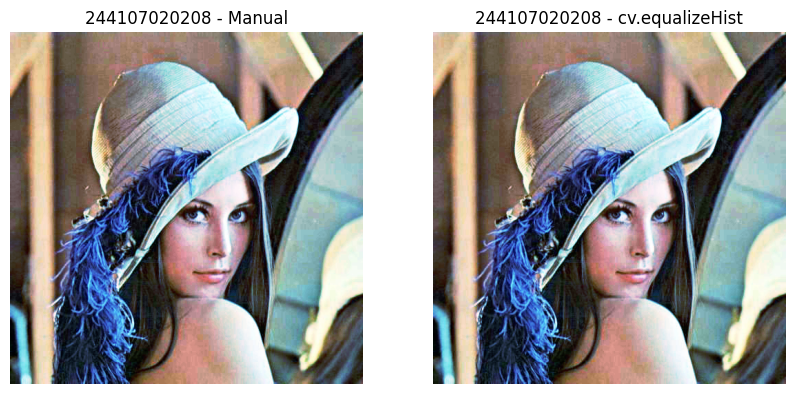

Selisih maksimum (KTM1a.jpg): 0


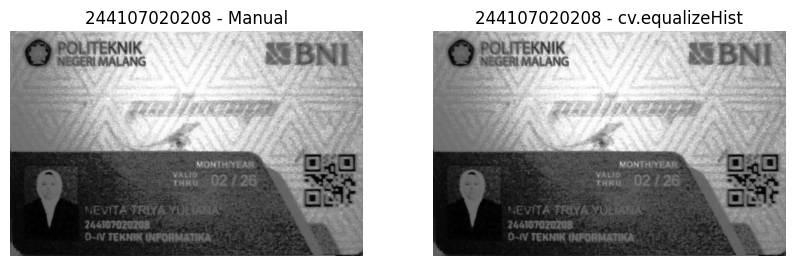

In [36]:
def he_cv_color(bgr):
    b, g, r = cv.split(bgr)
    b_equalized = cv.equalizeHist(b)
    g_equalized = cv.equalizeHist(g)
    r_equalized = cv.equalizeHist(r)
    return cv.merge([b_equalized, g_equalized, r_equalized])

# --- Verifikasi pada lena_lc.jpg ---
bgr_lc = safe_imread(f'{BASE}/lena_lc.jpg')
he_cv_lena = he_cv_color(bgr_lc)
selisih_lena = np.max(np.abs(he_manual_lena.astype(int) - he_cv_lena.astype(int)))
print('Selisih maksimum (lena_lc.jpg):', selisih_lena)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(cv.cvtColor(he_manual_lena, cv.COLOR_BGR2RGB)); ax[0].set_title(NIM + ' - Manual'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(he_cv_lena, cv.COLOR_BGR2RGB)); ax[1].set_title(NIM + ' - cv.equalizeHist'); ax[1].axis('off')
plt.show()

# --- Penilaian pada KTM1a.jpg  ---
gray_a = cv.cvtColor(safe_imread(f'{BASE}/KTM1a.jpeg'), cv.COLOR_BGR2GRAY)
he_manual_a = histogram_equalization_manual(gray_a)
he_cv_a = cv.equalizeHist(gray_a)
selisih_a = np.max(np.abs(he_manual_a.astype(int) - he_cv_a.astype(int)))
print('Selisih maksimum (KTM1a.jpg):', selisih_a)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(he_manual_a, cmap='gray'); ax[0].set_title(NIM + ' - Manual'); ax[0].axis('off')
ax[1].imshow(he_cv_a, cmap='gray'); ax[1].set_title(NIM + ' - cv.equalizeHist'); ax[1].axis('off')
plt.show()

**Penjelasan penyebab selisih tsb apabila tidak nol adalah hasil perbandingan menunjukkan selisih maksimum piksel sebesar 0 antara implementasi manual dan cv.equalizeHist, baik pada citra lena_lc.jpg maupun KTM1a.jpg. Ini membuktikan bahwa implementasi manual histogram equalization yang dibuat (menggunakan rumus Ko = round(CDF x 255)) telah sesuai persis dengan algoritma yang digunakan OpenCV secara internal.**

## 3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kaliterpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalanka npotongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya

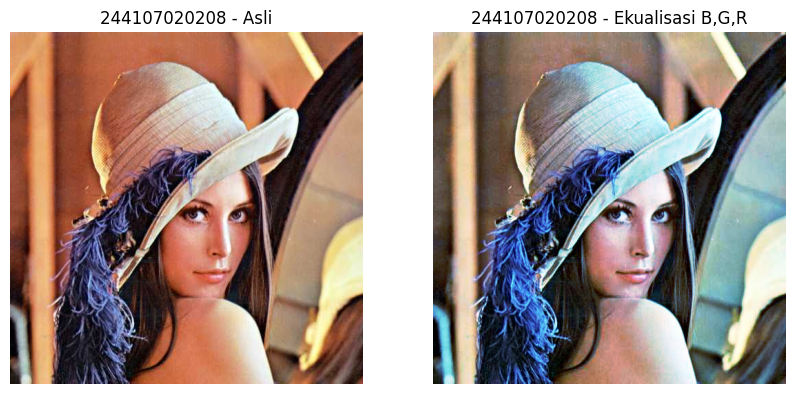

In [37]:
berkas = BASE + '/lena.jpg'
bgr = safe_imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB)); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)); ax[1].set_title(NIM + ' - Ekualisasi B,G,R'); ax[1].axis('off')
plt.show()

## 4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan KTM1d.jpg)

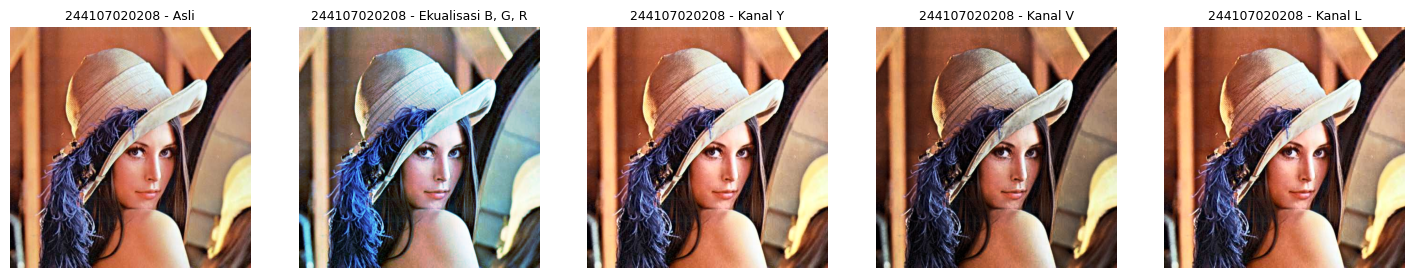

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7


In [38]:
# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# varian setara pada ruang warna lain
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()


def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d) # Hue melingkar 0-179
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                  cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

### Catatan Pengamatan Visual:


*   Citra asli: Citra tampak terlalu terang (efek cahaya matahari langsung), detail watermark dan tepi kartu pudar, kontras rendah.
*   Ekualisasi kanal B, G, R: Warna kartu berubah drastis, tampak semburat hijau/tidak natural terutama pada area putih dan tulisan polinema, kontras meningkat tapi warna asli kartu tidak lagi akurat.


*   Kanal Y (YCrCb): Kontras meningkat, warna kartu relatif terjaga mendekati aslinya, namun ada sedikit pergeseran nuansa dibanding kanal V.
*   Kanal V (HSV): Warna paling stabil dan natural di antara semua cara, kontras meningkat cukup baik, teks NIM dan nama lebih terbaca, sedikit lebih gelap dibanding Kanal Y/L.


*   Kanal L (LAB): Kecerahan meningkat merata, namun pergeseran warna sedikit lebih terasa dibanding Kanal V, terutama pada area tulisan polinema.

## Jawab Pertanyaan sesuai tabel diatas:

### 1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra Anda?
**Jawab: Ini jauh lebih besar dibanding cara lain (Kanal Y: 3.47°, Kanal V: 1.81°, Kanal L: 5.62°) karena ekualisasi B, G, R dilakukan terpisah per kanal warna, sehingga rasio antar kanal berubah drastis.**
### 2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra dikembalikan ke ruang warna BGR.
**Jawab: Ekualisasi kanal terang tetap mengubah pergeseran Hue karena proses konversi ruang warna bolak-balik (BGR → YCrCb/HSV/LAB → BGR) melibatkan perhitungan floating-point, sedangkan citra disimpan dalam uint8 (0-255). Setiap konversi balik memaksa OpenCV membulatkan nilai pecahan dan memotong nilai yang melebihi 0-255. Karena ekualisasi mengubah kecerahan secara signifikan, akumulasi pembulatan dan pemotongan ini menggeser sedikit rasio R:G:B dari aslinya sehingga Hue ikut bergeser meski nilainya kecil (Y: 3.47°, V: 1.81°, L: 5.62°).**
### 3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkanalasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.
**Jawab: Kanal V (HSV) paling sesuai, karena menghasilkan pergeseran Hue paling kecil (1.81°, vs Y 3.47° dan L 5.62°) sehingga warna asli kartu biru identitas dan merah latar foto tetap paling natural dan tidak berubah drastis seperti pada Ekualisasi B,G,R (yang tampak kehijauan). Dasar penilaian ini terlihat jelas pada area foto wajah (latar merah) dan bidang biru identitas kampus.**
### 4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil ekualisasi biasa.

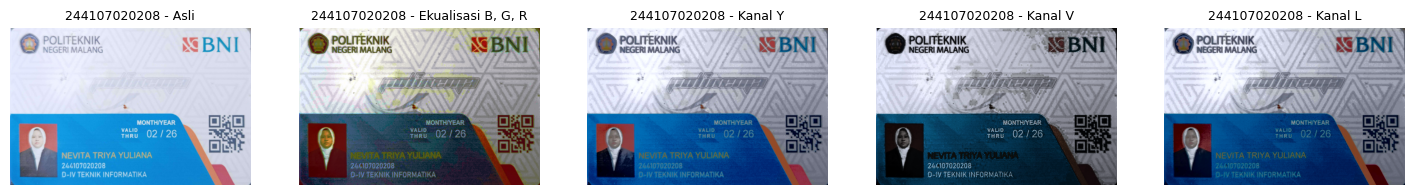

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            182.3
Ekualisasi B, G, R                67.49            129.5
Kanal Y                            3.47            133.9
Kanal V                            1.81            112.2
Kanal L                            5.62            124.3
Kanal V + equalizeHist
  geser Hue : 1.81°
  terang    : 112.18

Kanal V + CLAHE (clip=2.5, tile=2)
  geser Hue : 0.82°
  terang    : 160.30


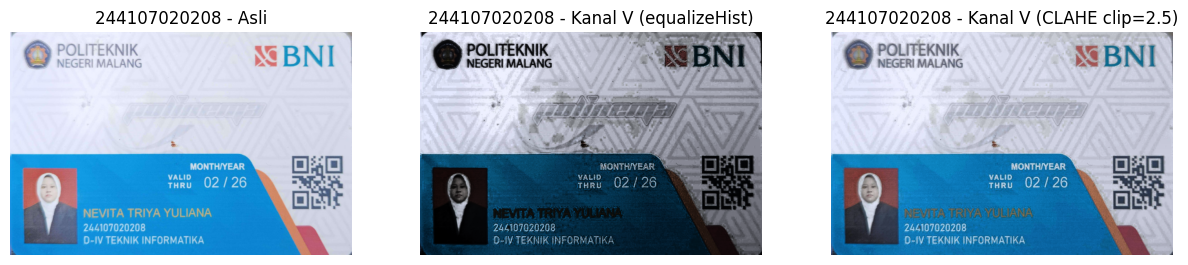

In [39]:
bgr = safe_imread(f'{BASE}/KTM1d.jpeg')

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                     cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

clahe_v = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
he_v_clahe = cv.cvtColor(cv.merge([h, sat, clahe_v.apply(v)]), cv.COLOR_HSV2BGR)

hue_eq    = geser_hue(bgr, he_v) * 2
terang_eq = cv.cvtColor(he_v, cv.COLOR_BGR2GRAY).mean()

hue_clahe    = geser_hue(bgr, he_v_clahe) * 2
terang_clahe = cv.cvtColor(he_v_clahe, cv.COLOR_BGR2GRAY).mean()

print(f"Kanal V + equalizeHist")
print(f"  geser Hue : {hue_eq:.2f}°")
print(f"  terang    : {terang_eq:.2f}")
print()
print(f"Kanal V + CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})")
print(f"  geser Hue : {hue_clahe:.2f}°")
print(f"  terang    : {terang_clahe:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB)); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(he_v, cv.COLOR_BGR2RGB)); ax[1].set_title(NIM + ' - Kanal V (equalizeHist)'); ax[1].axis('off')
ax[2].imshow(cv.cvtColor(he_v_clahe, cv.COLOR_BGR2RGB)); ax[2].set_title(NIM + f' - Kanal V (CLAHE clip={PARAM["clip"]})'); ax[2].axis('off')
plt.show()

**Jawab: CLAHE unggul di kedua metrik, Hue bergeser lebih kecil (turun ~55%) dan kecerahan lebih tinggi (naik ~43%). Ini karena equalizeHist meregangkan kontras secara global, sehingga pada foto dengan pencahayaan tidak merata (KTM1d.jpeg, difoto dengan cahaya matahari) remapping-nya ekstrem dan memicu pembulatan/pemotongan lebih besar. CLAHE bekerja lokal per-tile dengan clipLimit yang membatasi penguatan kontras, sehingga perubahan piksel lebih halus sekaligus mampu mengangkat kecerahan area lokal yang kurang terang tanpa terhambat piksel yang sudah sangat terang di area lain.**

# PERTANYAAN PRAKTIKUM E2
## 1. Ekualisasi Global pada KTM1a.jpg (poin a, b, c sekaligus)

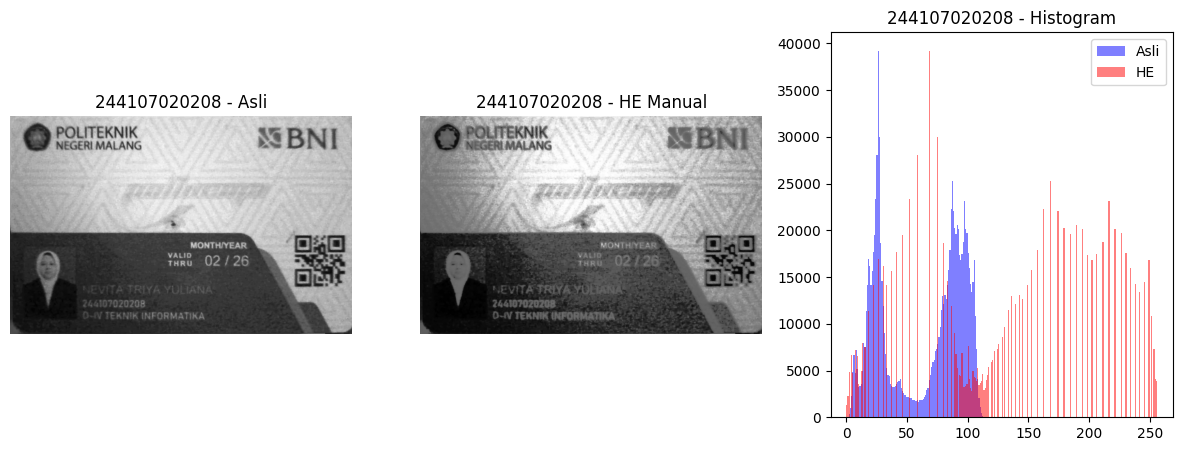

Selisih maksimum Manual vs cv.equalizeHist (KTM1a.jpg): 0
PSNR (Asli vs HE Manual): 10.133443710113763 dB


In [40]:
import numpy as np, cv2 as cv, matplotlib.pyplot as plt, math

def histogram_equalization_manual(gray):
    h_img, w_img = gray.shape
    h_hist, _ = np.histogram(gray, bins=256, range=(0,256))
    p = h_hist / (h_img * w_img)
    cdf = np.cumsum(p)
    Ko = np.round(cdf * 255).astype(np.uint8)
    return Ko[gray]

def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

# a. Ekualisasi manual & cv.equalizeHist pada KTM1a.jpg grayscale
gray_a = cv.cvtColor(safe_imread(f'{BASE}/KTM1a.jpeg'), cv.COLOR_BGR2GRAY)
he_manual_a = histogram_equalization_manual(gray_a)
he_cv_a = cv.equalizeHist(gray_a)

# b. Tampilkan asli, hasil ekualisasi, dan histogram dalam satu layout
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].imshow(gray_a, cmap='gray'); axs[0].set_title(NIM + ' - Asli'); axs[0].axis('off')
axs[1].imshow(he_manual_a, cmap='gray'); axs[1].set_title(NIM + ' - HE Manual'); axs[1].axis('off')
axs[2].hist(gray_a.ravel(), bins=256, range=(0,256), alpha=0.5, label='Asli', color='blue')
axs[2].hist(he_manual_a.ravel(), bins=256, range=(0,256), alpha=0.5, label='HE', color='red')
axs[2].legend(); axs[2].set_title(NIM + ' - Histogram')
plt.show()

# Verifikasi manual vs cv.equalizeHist
selisih_a = np.max(np.abs(he_manual_a.astype(int) - he_cv_a.astype(int)))
print('Selisih maksimum Manual vs cv.equalizeHist (KTM1a.jpg):', selisih_a)

# c. Hitung PSNR
psnr_val = PSNR(gray_a, he_manual_a)
print('PSNR (Asli vs HE Manual):', psnr_val, 'dB')

**Penjelasannya: PSNR mengukur kemiripan nilai piksel antara citra asli dan hasil olahan jadi semakin mirip nilainya, semakin tinggi PSNR. Histogram Equalization sengaja mengubah nilai piksel secara signifikan untuk meregangkan kontras sehingga sebaran intensitasnya lebih merata. Karena nilai piksel hasil HE memang jauh berbeda dari nilai piksel aslinya, MSE-nya besar sehingga PSNR-nya turun padahal secara visual citra hasil HE justru lebih mudah dibaca mata manusia karena kontrasnya meningkat.**

**Kesimpulan: PSNR tidak layak dipakai untuk menilai keterbacaan/kualitas visual sebuah citra dalam konteks perbaikan kontras seperti ini, karena PSNR hanya mengukur kesamaan numerik terhadap citra asli, bukan seberapa mudah citra tersebut dipahami/dibaca oleh manusia.**

## 2. Ekualisasi Lokal dengan CLAHE (poin a, b)

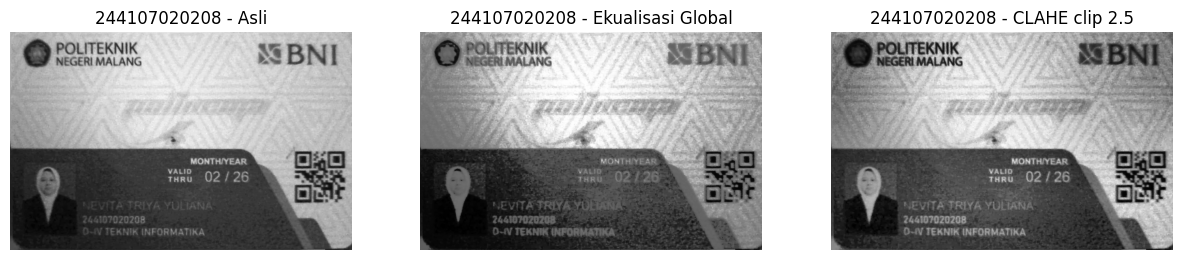

In [41]:
# a. CLAHE pada KTM1a.jpg dengan parameter dari NIM
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
he_clahe = clahe.apply(gray_a)
he_global = cv.equalizeHist(gray_a)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(gray_a, cmap='gray')
ax[0].set_title(NIM + ' - Asli')
ax[0].axis('off')

ax[1].imshow(he_global, cmap='gray')
ax[1].set_title(NIM + ' - Ekualisasi Global')
ax[1].axis('off')

ax[2].imshow(he_clahe, cmap='gray')
ax[2].set_title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))
ax[2].axis('off')
plt.show()

**Penjelasannya: Dari hasil di atas, CLAHE (clip 2.5) membuat NIM dan nama pada kartu lebih terbaca dibanding Ekualisasi Global. Pada hasil Ekualisasi Global, area foto dan sebagian teks NIM justru tampak lebih gelap/kurang kontras dibanding aslinya, karena histogram diregangkan untuk keseluruhan citra sekaligus sehingga area foto menarik proses ekualisasi ke arahnya. CLAHE bekerja per blok lokal, sehingga area pita NIM mendapat penguatan kontras sesuai kondisi lokalnya sendiri, menghasilkan teks NIM dan nama yang lebih jelas terbaca tanpa mengorbankan bagian lain kartu.**

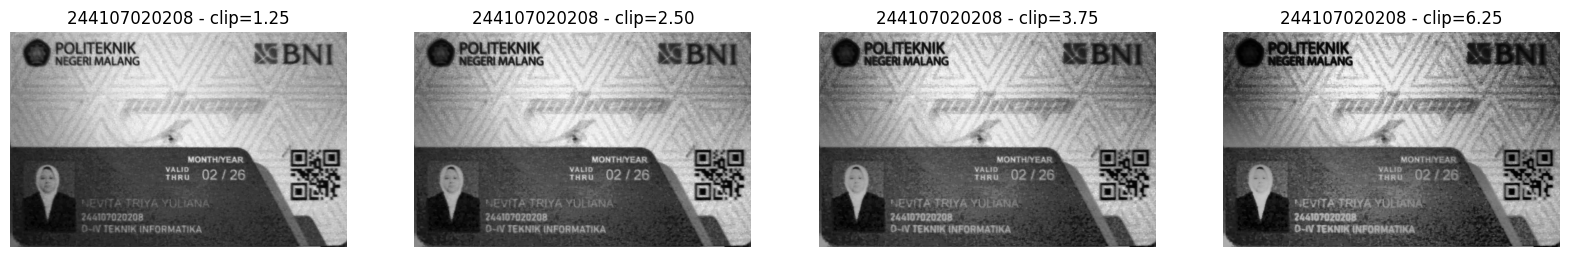

In [42]:
# b. Coba 3 nilai clipLimit lain di sekitar nilai PARAM['clip']
clip_values = [PARAM['clip']*0.5, PARAM['clip'], PARAM['clip']*1.5, PARAM['clip']*2.5]

fig, axs = plt.subplots(1, len(clip_values), figsize=(20,5))
for i, cval in enumerate(clip_values):
    clahe_i = cv.createCLAHE(clipLimit=cval, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil_i = clahe_i.apply(gray_a)
    axs[i].imshow(hasil_i, cmap='gray')
    axs[i].set_title(NIM + f' - clip={cval:.2f}')
    axs[i].axis('off')
plt.show()

**Penjelasannya: Semakin besar clipLimit (1.25 → 2.50 → 3.75 → 6.25), kontras kartu semakin kuat namun noise/bintik pada background kartu (area pola segitiga polinema) semakin menonjol, terlihat jelas mulai clip=3.75 dan makin parah di clip=6.25. Nilai clip=2.50 dipilih sebagai yang terbaik, karena NIM dan nama sudah cukup terbaca jelas tanpa noise berlebihan yang mengganggu, sedangkan clip=1.25 kontrasnya masih kurang tajam dan clip di atas 3.75 sudah terlalu banyak bintik noise pada background.**

# E-3 TUGAS PRAKTIKUM DITHERING


In [43]:
def floyd_steinberg_color(bgr, L=2):
    """Terapkan Floyd-Steinberg ke tiap kanal warna B, G, R secara terpisah"""
    b, g, r = cv.split(bgr)
    b_dither = floyd_steinberg(b, L)
    g_dither = floyd_steinberg(g, L)
    r_dither = floyd_steinberg(r, L)
    return cv.merge([b_dither, g_dither, r_dither])

## 1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi pada KTM1b.jpg dengan jumlah level PARAM['L'].
### Tahap 1:

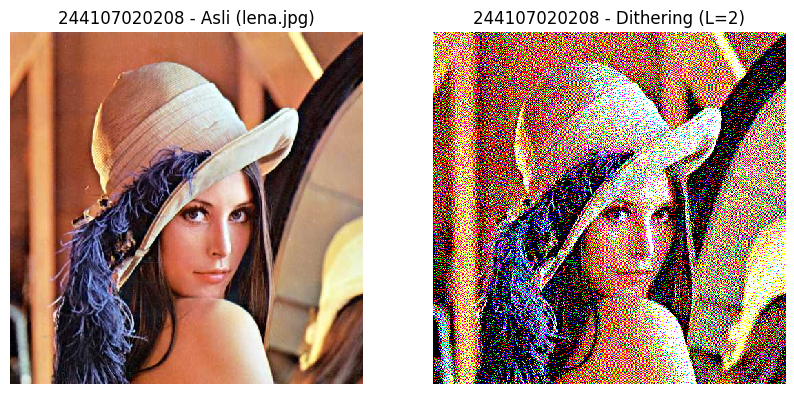

In [44]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                     img[y, x+1]   += error * 7 / 16
            if x > 0 and y+1 < H:              img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                      img[y+1, x]   += error * 5 / 16
            if x + 1 < W and y+1 < H:          img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def floyd_steinberg_color(bgr, L=2):
    """Terapkan Floyd-Steinberg ke tiap kanal warna B, G, R secara terpisah"""
    b, g, r = cv.split(bgr)
    b_dither = floyd_steinberg(b, L)
    g_dither = floyd_steinberg(g, L)
    r_dither = floyd_steinberg(r, L)
    return cv.merge([b_dither, g_dither, r_dither])

bgr_lena = safe_imread(f'{BASE}/lena.jpg')
dither_lena_color = floyd_steinberg_color(bgr_lena, L=2)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(cv.cvtColor(bgr_lena, cv.COLOR_BGR2RGB), interpolation='nearest')
ax[0].set_title(NIM + ' - Asli (lena.jpg)'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(dither_lena_color, cv.COLOR_BGR2RGB), interpolation='nearest')
ax[1].set_title(NIM + ' - Dithering (L=2)'); ax[1].axis('off')
plt.show()

### Tahap 2:

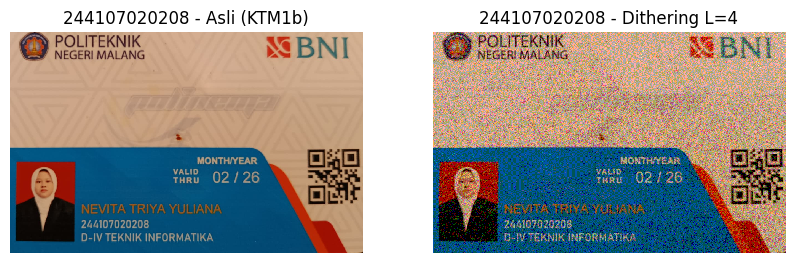

In [45]:
bgr_b = safe_imread(f'{BASE}/KTM1b.jpeg')
dither_b_color = floyd_steinberg_color(bgr_b, L=PARAM['L'])

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(cv.cvtColor(bgr_b, cv.COLOR_BGR2RGB), interpolation='nearest')
ax[0].set_title(NIM + ' - Asli (KTM1b)'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(dither_b_color, cv.COLOR_BGR2RGB), interpolation='nearest')
ax[1].set_title(NIM + f" - Dithering L={PARAM['L']}"); ax[1].axis('off')
plt.show()

**Penjelasannya: Proses dithering Floyd-Steinberg mengubah citra dari kedalaman warna penuh (256 level per kanal) menjadi jumlah level yang jauh lebih sedikit (L=2 untuk lena.jpg, L=PARAM['L']=4 untuk KTM1b.jpg). Setiap piksel dikuantisasi ke level terdekat, dan selisih (error) antara nilai asli dan nilai hasil kuantisasi disebarkan ke piksel-piksel tetangga yang belum diproses, dengan bobot 7/16, 3/16, 5/16, dan 1/16 sesuai kernel Floyd-Steinberg. Hasilnya, meskipun jumlah warna yang benar-benar dipakai sangat sedikit, secara visual gambar tetap terlihat halus dan bentuknya masih dikenali karena error yang terdifusi menciptakan pola noise/tekstur yang secara optik "mengaburkan" batas antar level warna, bukan menghasilkan blok-blok warna kasar seperti kuantisasi biasa tanpa error diffusion.**

## 2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaranintensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang menghasilkan teks pada KTM lebih terbaca.
### Tahap 1:

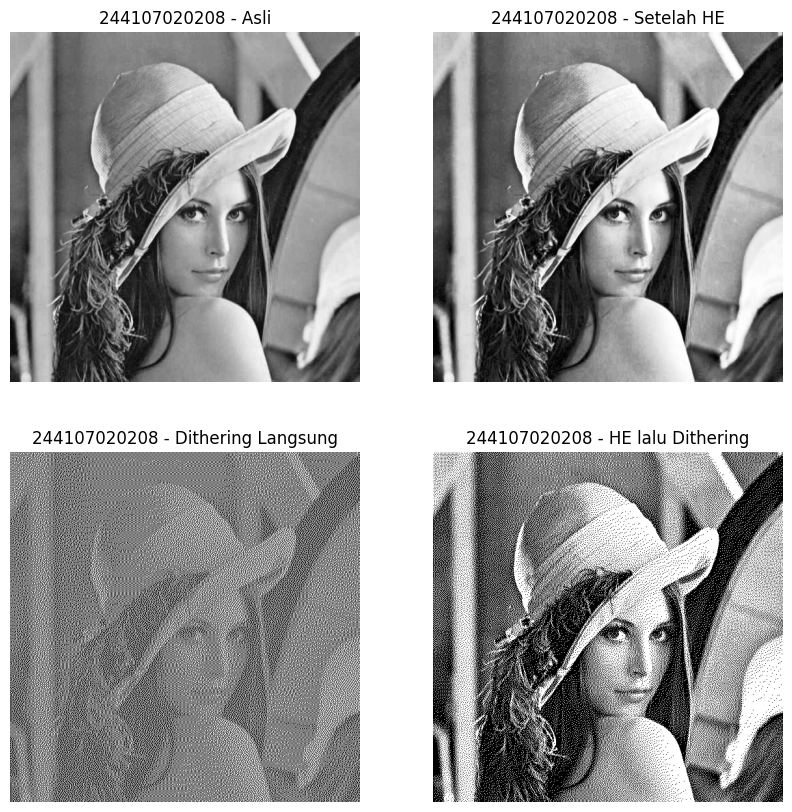

In [46]:
gray_lc = cv.cvtColor(safe_imread(f'{BASE}/lena_lc.jpg'), cv.COLOR_BGR2GRAY)
he_lc = cv.equalizeHist(gray_lc)
dither_lc_langsung = floyd_steinberg(gray_lc, L=2)
dither_lc_setelah_he = floyd_steinberg(he_lc, L=2)

fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax[0,0].imshow(gray_lc, cmap='gray'); ax[0,0].set_title(NIM + ' - Asli'); ax[0,0].axis('off')
ax[0,1].imshow(he_lc, cmap='gray'); ax[0,1].set_title(NIM + ' - Setelah HE'); ax[0,1].axis('off')
ax[1,0].imshow(dither_lc_langsung, cmap='gray'); ax[1,0].set_title(NIM + ' - Dithering Langsung'); ax[1,0].axis('off')
ax[1,1].imshow(dither_lc_setelah_he, cmap='gray'); ax[1,1].set_title(NIM + ' - HE lalu Dithering'); ax[1,1].axis('off')
plt.show()

**Penjelasannya: Verifikasi kuantitatif menunjukkan hasil dithering pada lena_lc.jpg hanya mengandung 2 nilai unik piksel, yaitu 0 dan 255, sesuai dengan parameter L=2 yang ditentukan. Ini membuktikan implementasi Floyd-Steinberg telah berhasil mengkuantisasi citra ke jumlah level yang benar, meskipun perbedaan pola visual detail (bintik vs pola garis) dengan gambar contoh di modul bisa terjadi akibat perbedaan karakteristik/resolusi file sumber, bukan kesalahan logika program.**
### Tahap 2:

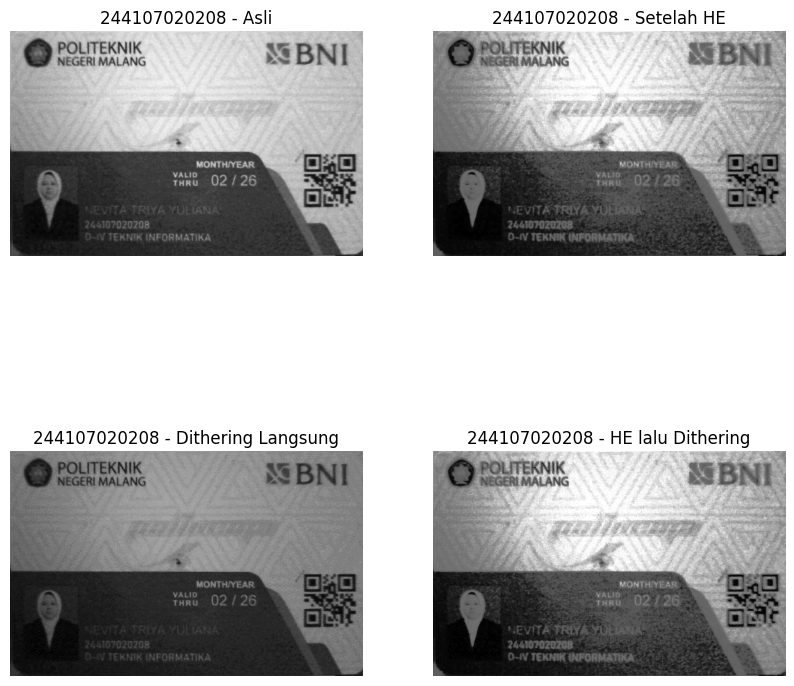

In [47]:
gray_a = cv.cvtColor(safe_imread(f'{BASE}/KTM1a.jpeg'), cv.COLOR_BGR2GRAY)
he_a = cv.equalizeHist(gray_a)
dither_a_langsung = floyd_steinberg(gray_a, L=PARAM['L'])
dither_a_setelah_he = floyd_steinberg(he_a, L=PARAM['L'])

fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax[0,0].imshow(gray_a, cmap='gray'); ax[0,0].set_title(NIM + ' - Asli'); ax[0,0].axis('off')
ax[0,1].imshow(he_a, cmap='gray'); ax[0,1].set_title(NIM + ' - Setelah HE'); ax[0,1].axis('off')
ax[1,0].imshow(dither_a_langsung, cmap='gray'); ax[1,0].set_title(NIM + ' - Dithering Langsung'); ax[1,0].axis('off')
ax[1,1].imshow(dither_a_setelah_he, cmap='gray'); ax[1,1].set_title(NIM + ' - HE lalu Dithering'); ax[1,1].axis('off')
plt.show()

**Penjelasannya: Melakukan Histogram Equalization terlebih dahulu sebelum Dithering menghasilkan teks yang lebih terbaca dibanding dithering langsung. Ini karena HE meregangkan kontras citra asli terlebih dulu, sehingga area teks (biasanya gelap/pekat) dan latar (biasanya terang) memiliki jarak intensitas yang lebih jauh sebelum proses kuantisasi dithering dilakukan. Ketika dithering langsung diterapkan pada citra asli dengan kontras rendah (seperti KTM1a yang difoto di ruangan gelap), kuantisasi ke level rendah (L=4) berisiko menghilangkan detail teks karena teks dan latarnya sudah terlalu mirip nilai intensitasnya sejak awal. Hal ini terlihat pada hasil percobaan: pada gambar "Dithering Langsung", bagian NIM dan nama tampak lebih sulit dibedakan dari latar kartu dibanding pada gambar "HE lalu Dithering", yang tulisannya tetap terbaca lebih jernih.**